🎉 恭喜！你已经拿到真实股票数据
   共 124 个交易日
   最新收盘价: $207.45


,Close,High,Low,Open,Volume
Date,,,,,
2026-07-08,204.119995,205.160004,195.059998,195.179993,147419100
2026-07-09,202.779999,204.589996,198.960007,204.460007,132037400
2026-07-10,210.960007,211.000000,201.919998,202.000000,148421000
2026-07-13,203.529999,210.570007,203.000000,208.539993,120943800
2026-07-14,207.450104,208.339996,203.800003,208.199997,33105233


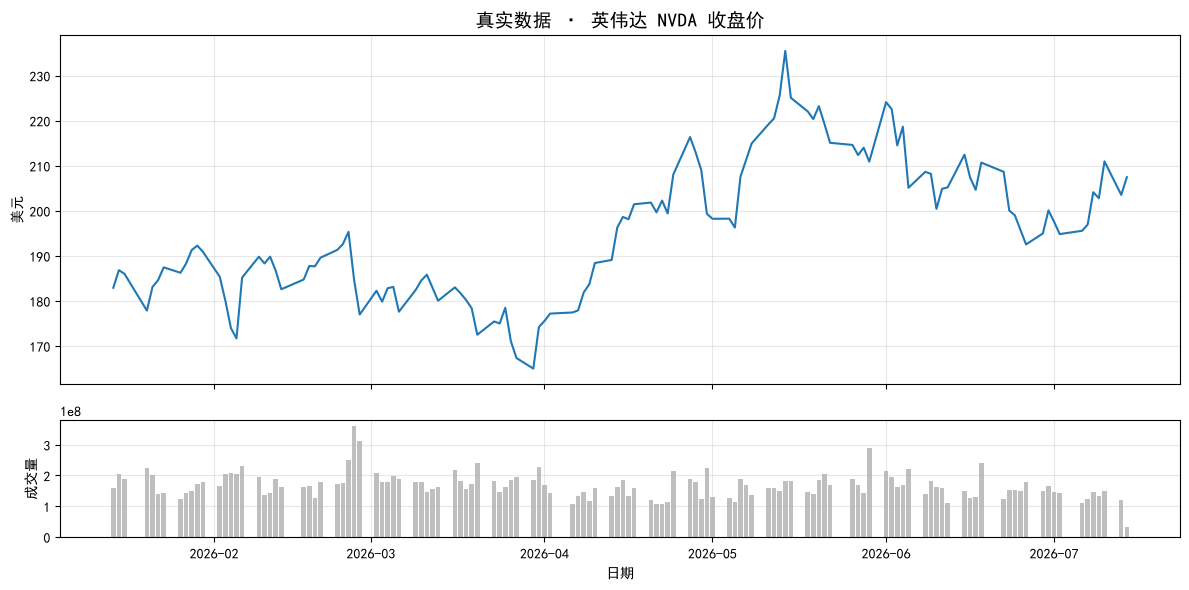

In [4]:
# ========== 第一章爽点：下载真实股票数据 ==========
import warnings                          # 导入警告控制模块
warnings.filterwarnings('ignore')   # 隐藏不影响学习的警告信息

import matplotlib.pyplot as plt     # 画图
import yfinance as yf               # 从雅虎财经免费下载行情

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False      # 坐标轴负号正常显示

# 一行下载*NVDA*最近 6 个月的日线（需要联网）
aapl = yf.download('NVDA', period='6mo', progress=False, multi_level_index=False)  # 下载股票日线行情
aapl.to_csv('nvda_data.csv')

print('🎉 恭喜！你已经拿到真实股票数据')  # 打印输出
print(f'   共 {len(aapl)} 个交易日')                              # 行数 = 交易日个数
print(f'   最新收盘价: ${aapl["Close"].iloc[-1]:.2f}')            # iloc[-1] = 最后一行
display(aapl.tail(5))   # 在 Notebook 里美观地显示最后 5 行表格

# ========== 上图收盘价、下图成交量 ==========
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,       # 2行子图，横轴对齐
                         gridspec_kw={'height_ratios': [3, 1]})    # 上图占 3 份高度
axes[0].plot(aapl.index, aapl['Close'], color='tab:blue', linewidth=1.5)  # 折线：收盘价
axes[0].set_title('真实数据 · 英伟达 NVDA 收盘价', fontsize=14)  # 设置上图标题
axes[0].set_ylabel('美元')  # 设置上图纵轴
axes[0].grid(True, alpha=0.3)  # 上图显示网格

axes[1].bar(aapl.index, aapl['Volume'], width=0.8, color='gray', alpha=0.5)  # 柱状：成交量
axes[1].set_ylabel('成交量')  # 设置下图纵轴
axes[1].set_xlabel('日期')  # 设置下图横轴（日期）
axes[1].grid(True, alpha=0.3)  # 下图显示网格

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('nvda_chart.png', dpi=150, bbox_inches='tight') #save
plt.show()                               # 在 Notebook 里显示图片
